In [7]:
"""
Comparing action-selection strategies on the k-armed bandit problem

Author: Puneet Sharma
## claude.ai is used to refine and correct this code

Methods compared:
    1. Greedy                          (epsilon = 0)
    2. Near-greedy (epsilon-greedy)    (epsilon = 0.1)
    3. Optimistic Initial Values       (Q1 = 5, greedy, alpha = 0.1)
    4. Upper-Confidence-Bound (UCB)    (c = 2)
    5. Softmax Bandit                 (action preferences -> softmax probabilities)


    - average reward per step (averaged over many independent runs)
    - percentage of time the optimal action was chosen
"""

import numpy as np
import matplotlib.pyplot as plt


# ----------------------------------------------------------------------
# Bandit environment
# ----------------------------------------------------------------------
class KArmedBandit:
#Stationary k-armed bandit. This acts as true value generator

    def __init__(self, k=10, seed=None):
        # see np.random see https://numpy.org/devdocs/reference/random/generator.html
        rng = np.random.default_rng(seed)
        self.k = k
        self.q_star = rng.normal(0, 1, k)      # true action values
        self.optimal_action = np.argmax(self.q_star) # true optimal action

    def step(self, action, rng):
        return rng.normal(self.q_star[action], 1)

# epsilon-Greedy Agent
class GreedyAgent:
#epsilon = 0 -> always exploit. Sample-average update.

    def __init__(self, k, epsilon=0.0, q_init=0.0):
        self.k = k
        self.epsilon = epsilon
        self.Q = np.full(k, q_init, dtype=float)
        # N, number of time action a has been selected
        self.N = np.zeros(k, dtype=int)

    def select_action(self, rng):
        # epsilon-greedy action selection, random() generates a scalar [0,1]
        if rng.random() < self.epsilon:
            return rng.integers(self.k)
        return np.argmax(self.Q) # select action with the best estimate

    def update(self, action, reward):
        #increment the count for action
        self.N[action] += 1
        # update the estimate using sample-average
        self.Q[action] += (reward - self.Q[action]) / self.N[action]


class OptimisticAgent:
## Optimistic initial values with constant step-size (encourages exploration)
## initial estimated reward for every action is optimistic 5.0
## alpha determines how strongly the agent reacts to each new reward

    def __init__(self, k, q_init=5.0, alpha=0.1, epsilon=0.0):
      self.k = k
      self.epsilon = epsilon
      self.alpha = alpha
      self.Q = np.full(k, q_init, dtype=float)

    def select_action(self, rng):
        if rng.random() < self.epsilon:
            return rng.integers(self.k)
        return np.argmax(self.Q)
  # update has alpha component which weights new rewards
  # otherwise quite similar to above
    def update(self, action, reward):
      self.Q[action] += self.alpha * (reward - self.Q[action])


class UCBAgent:
##  Upper-Confidence-Bound action selection
##   Choose actions that either have high estimated rewards or
##   have not yet been explored enough.

    def __init__(self, k, c=2.0):
        self.k = k
        self.c = c #exploration coefficient
        self.Q = np.zeros(k, dtype=float)
        self.N = np.zeros(k, dtype=int)
        self.t = 0 # t increases every time select_action() is called.

    def select_action(self, rng):
        self.t += 1
        untried = np.where(self.N == 0)[0]
        # as long as untried actions are >0
        if len(untried) > 0:
            return rng.choice(untried)
        # estimated value part +  exploration part
        ucb = self.Q + self.c * np.sqrt(np.log(self.t) / self.N)
        return np.argmax(ucb)
    # similar to other agents (above)
    def update(self, action, reward):
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]


class SoftmaxBanditAgent:
    """Action preferences H(a) converted to probabilities via softmax,
    updated with the REINFORCE-style rule using a reward baseline."""

    def __init__(self, k, alpha=0.1, use_baseline=True):
        self.k = k
        # how much the prefernce changes after each reward
        self.alpha = alpha
        self.H = np.zeros(k, dtype=float)
        # whether to use the average reward as a baseline in the update

        self.use_baseline = use_baseline
        self.avg_reward = 0.0
        self.t = 0
    #Computing action probabilities
    def _probs(self):
        exp_h = np.exp(self.H - np.max(self.H))  # numerical stability
        return exp_h / np.sum(exp_h)

    def select_action(self, rng):
        self.probs = self._probs()
        #Randomly chooses one action according to those probabilities
        return rng.choice(self.k, p=self.probs)

    def update(self, action, reward):
        self.t += 1
        # with use_baseline=True, use the average reward;
        # with use_baseline=False, use 0.0.
        if self.use_baseline:
            self.avg_reward += (reward - self.avg_reward) / self.t
        baseline = self.avg_reward if self.use_baseline else 0.0

        one_hot = np.zeros(self.k)
        one_hot[action] = 1.0
        self.H += self.alpha * (reward - baseline) * (one_hot - self.probs)



In [8]:

# ----------------------------------------------------------------------
# Experiment with different strategies
# ----------------------------------------------------------------------

K = 10 # number of arms
N_RUNS = 2000
N_STEPS = 1000

## dictionary
## lambda is delays agent creation until each run starts.
## For lambda see https://www.thepythoncodingstack.com/p/whats-all-the-fuss-about-python-lambda-functions

methods = {
    "Greedy (eps=0)":            lambda: GreedyAgent(K, epsilon=0.0),
    "Eps-greedy (eps=0.1)":      lambda: GreedyAgent(K, epsilon=0.1),
    "Optimistic (Q1=5, a=0.1)":  lambda: OptimisticAgent(K, q_init=5.0, alpha=0.1, epsilon=0.0),
    "UCB (c=2)":                 lambda: UCBAgent(K, c=2.0),
    "Softmax bandit":            lambda: SoftmaxBanditAgent(K, alpha=0.1, use_baseline=True),
}

rewards = {name: np.zeros(N_STEPS) for name in methods}
optimal_pct = {name: np.zeros(N_STEPS) for name in methods}

# methods loop
for name, make_agent in methods.items():
    print(f"Running {name} ...")
    run_rewards = np.zeros((N_RUNS, N_STEPS))
    run_optimal = np.zeros((N_RUNS, N_STEPS))

    # runs loop (e.g., 2000 differnet experiments)
    for run in range(N_RUNS):
        bandit = KArmedBandit(k=K, seed=run)     # new random problem each run
        rng = np.random.default_rng(run + 100000)  # separate rng for action selection/noise
        agent = make_agent()
        # Steps loop (e.g., 1000 decisions in one experiment)
        for t in range(N_STEPS):
            action = agent.select_action(rng)
            reward = bandit.step(action, rng)
            agent.update(action, reward)

            run_rewards[run, t] = reward
            run_optimal[run, t] = 1.0 if action == bandit.optimal_action else 0.0

    rewards[name] = run_rewards.mean(axis=0)
    optimal_pct[name] = run_optimal.mean(axis=0) * 100



Running Greedy (eps=0) ...
Running Eps-greedy (eps=0.1) ...
Running Optimistic (Q1=5, a=0.1) ...
Running UCB (c=2) ...
Running Softmax bandit ...


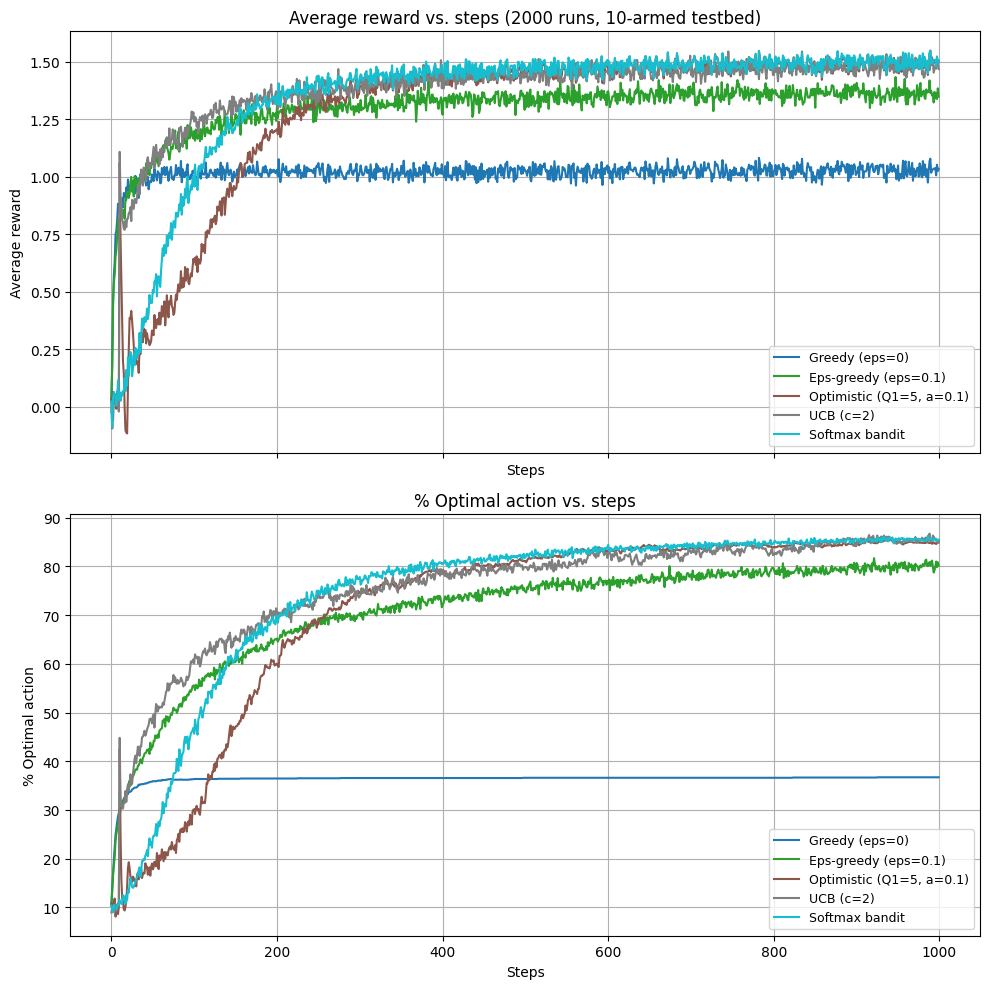

In [10]:

# ----------------------------------------------------------------------
# Plotting
# ----------------------------------------------------------------------
colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))

fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

for (name, r), c in zip(rewards.items(), colors):
    axes[0].plot(r, label=name, color=c, linewidth=1.5)
axes[0].set_xlabel("Steps")
axes[0].set_ylabel("Average reward")
axes[0].set_title(f"Average reward vs. steps ({N_RUNS} runs, {K}-armed testbed)")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].grid()

for (name, p), c in zip(optimal_pct.items(), colors):
    axes[1].plot(p, label=name, color=c, linewidth=1.5)
axes[1].set_xlabel("Steps")
axes[1].set_ylabel("% Optimal action")
axes[1].set_title("% Optimal action vs. steps")
axes[1].legend(loc="lower right", fontsize=9)
axes[1].grid()

plt.tight_layout()
